In [2]:
import numpy as np
import pandas as pd
import xarray as xr

%matplotlib inline
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib import colors
from matplotlib.patches import Rectangle
from matplotlib.tri import Triangulation

from copy import copy

# Creation of a new tagging region file

For tagging, WAM2layers relies on a netCDF file spanning the tracking region. The only data variable is "source_region", which is 1 at all grid points for which the precipitation is supposed to be tracked. Here I create a new file, which includes the expanded source region.

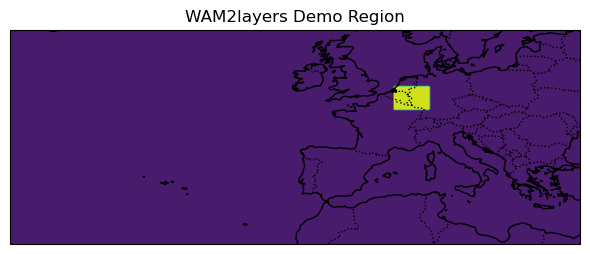

In [3]:
ds_region = xr.open_dataset("data/moisture_tracking/blcklst_wlt/region-eiffel.nc") #old tagging file

fig, ax = plt.subplots(1, 1, figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.tight_layout(w_pad=2)

ax.contourf(ds_region["longitude"], ds_region["latitude"], ds_region["source_region"])

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set(title="WAM2layers Demo Region")

plt.show()

In [7]:
ds = xr.open_dataset("./data/moisture_tracking/blcklst_wlt/icon_R03B07_tp_original_20210714.nc") #some arbitrary file to be visualized

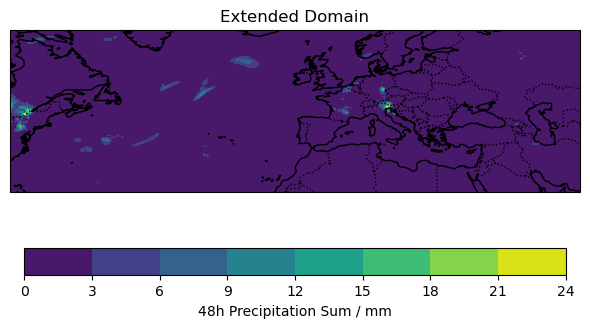

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.tight_layout(w_pad=2)

# Plot of data A:
im = ax.contourf(ds["lon"], ds["lat"], ds["TOT_PREC"].isel(time=0))
plt.colorbar(im, ax=ax, location="bottom", label="48h Precipitation Sum / mm", shrink=0.95)

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set(title="Extended Domain")

plt.show()

Create new tagging mask from data file:

In [ ]:
# Extent of the new tagging region:
# lat 49 to 52 N
# lon 4 to 8.75 E

mask = (ds["lon"] >= 4) & (ds["lon"] <= 9) & (ds["lat"] >= 49) & (ds["lat"] <= 52)
vals = np.zeros((ds.sizes["lat"], ds.sizes["lon"]), dtype=np.float32)
vals[mask.T] = 1.

ds_new_region = xr.Dataset(
    data_vars={
        "source_region": (["latitude", "longitude"], vals)
    },
    coords={
        "longitude": ds["lon"].values,
        "latitude": ds["lat"].values
    }
)

# ds_new_region.to_netcdf("data/moisture_tracking/blcklst_wlt/expanded_region.nc") # and save it

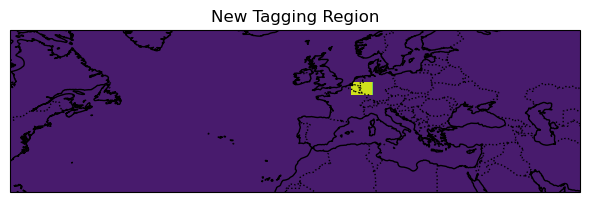

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.tight_layout(w_pad=2)

# Plot of data A:
ax.contourf(ds_new_region["longitude"], ds_new_region["latitude"], ds_new_region["source_region"])

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set(title="New Tagging Region")

plt.show()

# Dis-aggregating precipitation and converting units

Due to the storage logic, 00UTC contains 21,22,23 and 00UTC. At 21UTC, precipitation is zero and the following time steps contain the accumulated sum of precipitation. Since WAM2layers expects hourly values (for now), I dis-aggregate them here. Also, I convert the units from mm in ICON to m as in ERA5 and that of evaporation from flux to column equivalent. Those are just factors of 1000 and 3.6 (see code). This is done, because I want to bring the data into the same format as ERA5, because that is what my modifications are based upon.

In [12]:
def diff_within_blocks_vectorized(da, block_size=3):
    """
    Vectorized version using groupby.
    """
    # Create block labels for grouping
    time_index = np.arange(len(da.time))
    block_labels = np.ceil(time_index / 3).astype(int)
    
    # Add block labels as a coordinate
    da_with_blocks = da.assign_coords(block=('time', block_labels))
    
    # Define a function to apply to each block
    def block_diff(block):
        if len(block.time) > 1:
            # Create a mask for all positions except the first in each block
            time_pos = xr.DataArray(range(len(block.time)), dims=['time'], coords={'time': block.time})
            mask = time_pos > 0
            
            # Shift the block by one position along time
            shifted = block.shift(time=1)
            
            # Use where to apply the difference only where mask is True
            return block.where(~mask, block - shifted)
        return block
    
    # Apply the function to each block and concatenate results
    result = da_with_blocks.groupby('block').map(block_diff)
    
    # Remove the block coordinate
    result = result.drop_vars('block')
    
    return result

This precipitation approach has the issue that I get some minimal negative values. I think this might be an artifact from the interpolation. In the interpolated, but accumulated files, everything still is positive by definition. But maybe the differences don't quite add up anymore. Since it's only minor negative values, it's probably safe to ignore.

In [13]:
exp_name = "blcklst_sat"

In [17]:
ds_tp = xr.open_mfdataset([f"data/moisture_tracking/{exp_name}/icon_R03B07_tp_original_202107{hh:02}.nc" for hh in range(1,16)])

da_diff = diff_within_blocks_vectorized(ds_tp["TOT_PREC"]) / 1000. # convert from mm to m

for dd in range(1,16):
    time_slice = slice(np.datetime64(f"2021-07-{dd:02}T00"), np.datetime64(f"2021-07-{dd:02}T23"))
    da_diff.sel(time=time_slice).to_netcdf(f"data/moisture_tracking/{exp_name}/icon_R03B07_tp_202107{dd:02}.nc")

For evaporation I just need to convert from kg^-2 s^-1 to column equivalent in m

In [15]:
ds_evap = xr.open_mfdataset([f"data/moisture_tracking/{exp_name}/icon_R03B07_e_original_202107{hh:02}.nc" for hh in range(1,16)])
for dd in range(1,16):
    time_slice = slice(np.datetime64(f"2021-07-{dd:02}T00"), np.datetime64(f"2021-07-{dd:02}T23"))
    (ds_evap["EVAPT"].sel(time=time_slice)*3.6).to_netcdf(f"data/moisture_tracking/{exp_name}/icon_R03B07_e_202107{dd:02}.nc")